In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def jam_model(t, y, Λ, β, θ, γ, μ1, μ2):
    S, I, R = y
    dSdt = Λ - β * S * I - μ1 * S
    dIdt = (1 + θ) * β * S * I - (γ + μ2) * I
    dRdt = γ * I + μ1 * S + μ2 * I
    return [dSdt, dIdt, dRdt] 

In [3]:
y0 = [6768, 34000, 0]

Λ = 2262   # Launch rate (2020-2024 average launches per year: 2262) 
β = 9 / ( y0[0]* y0[1]) # Collision rate
θ = 29   # the number of fragments generated per S–I collision, in addition to the intact object that gets destroyed
γ = 0   # Mition rate (ADR/I) (active debris removal ADR currently 0 but this is where space debris missions could help)
μ1 = 250/y0[0]   
μ2 = 450/y0[1] 

In [4]:
t_span = (0, 50)
t_eval = np.linspace(*t_span, 1000)

In [5]:
sol = solve_ivp(jam_model, t_span, y0, args=(Λ, β, θ, γ, μ1, μ2), t_eval=t_eval)

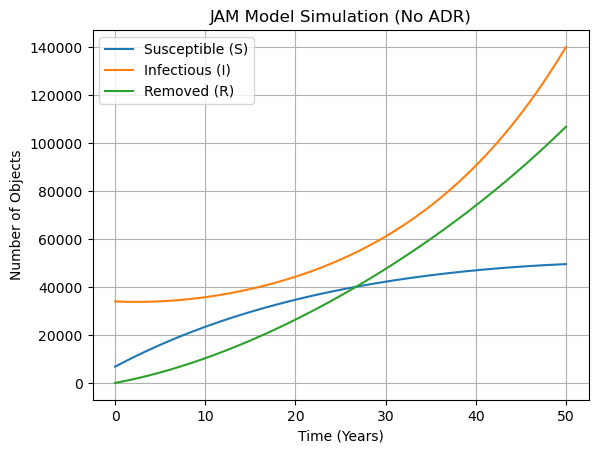

In [6]:
plt.plot(sol.t, sol.y[0], label='Susceptible (S)')
plt.plot(sol.t, sol.y[1], label='Infectious (I)')
plt.plot(sol.t, sol.y[2], label='Removed (R)')
plt.xlabel('Time (Years)')
plt.ylabel('Number of Objects')
plt.title('JAM Model Simulation (No ADR)')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
def compute_R0(β, θ, γ, μ1, μ2, Λ):
    return ((1 + θ) * β * Λ )/ (μ1 * (γ + μ2))


R0 = compute_R0(β, θ, γ, μ1, μ2, Λ)
print(f"R0 = {R0:.3f}")

R0 = 5.429


In [8]:
S_array = sol.y[0] 

def compute_Rt(S_array, β, θ, γ, μ2):
    return (1 + θ) * β * S_array / (γ + μ2)

In [9]:
time_array = t_eval 
Rt_values = compute_Rt(S_array, β, θ, γ, μ2)

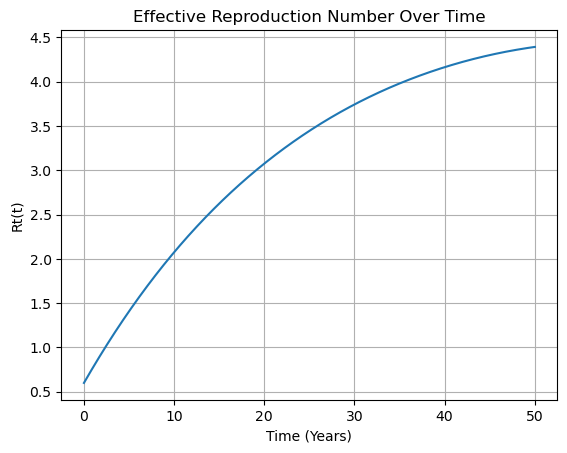

In [10]:
plt.plot(time_array, Rt_values)
plt.xlabel("Time (Years)")
plt.ylabel("Rt(t)")
plt.title("Effective Reproduction Number Over Time")
plt.grid(True)
plt.show()

Max R_t(t): 4.39
Theoretical R0: 5.43


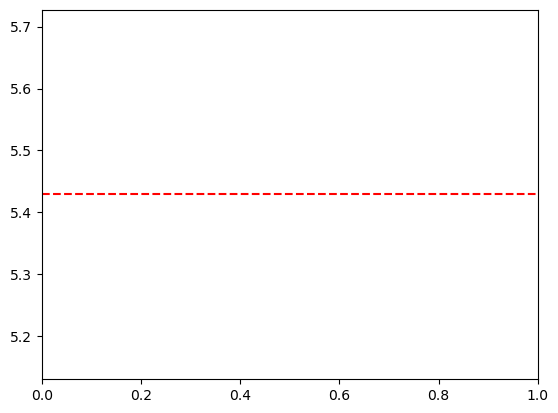

In [11]:
print(f"Max R_t(t): {max(Rt_values):.2f}")
print(f"Theoretical R0: {R0:.2f}")
plt.axhline(R0, linestyle='--', color='red', label='R0')

<function matplotlib.pyplot.tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)>

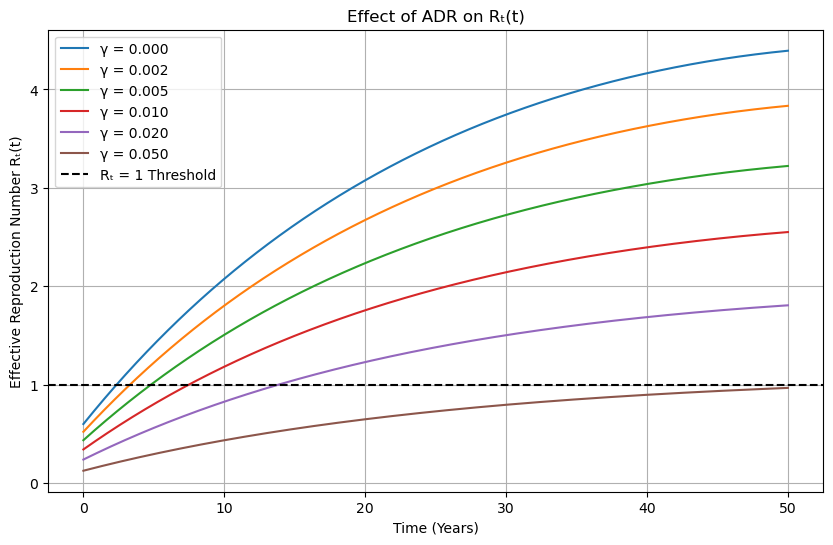

In [12]:
gamma_values = [0, 0.002, 0.005, 0.01, 0.02, 0.05]

plt.figure(figsize=(10, 6))

for γ in gamma_values:
    sol = solve_ivp(jam_model, t_span, y0, args=(Λ, β, θ, γ, μ1, μ2), t_eval=t_eval)
    S, I, R = sol.y

    Rt = ((1 + θ) * β * S) / (γ + μ2)
    label = f"γ = {γ:.3f}"

    plt.plot(t_eval, Rt, label=label)

plt.axhline(1, linestyle='--', color='black', label='Rₜ = 1 Threshold')
plt.xlabel("Time (Years)")
plt.ylabel("Effective Reproduction Number Rₜ(t)")
plt.title("Effect of ADR on Rₜ(t)")
plt.legend()
plt.grid(True)
plt.tight_layout

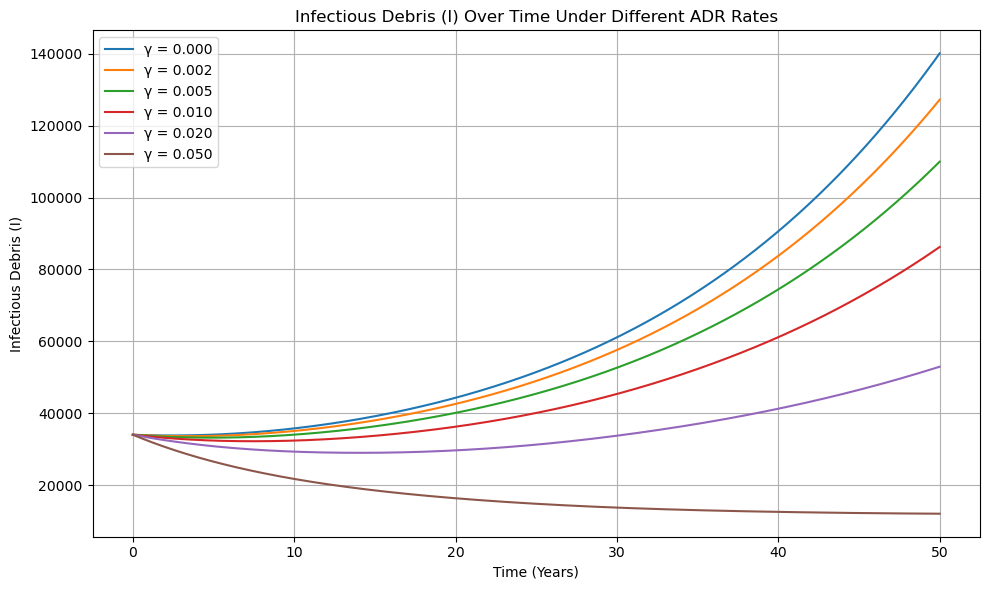

In [13]:
plt.figure(figsize=(10, 6))

for γ in gamma_values:
    sol = solve_ivp(jam_model, t_span, y0, args=(Λ, β, θ, γ, μ1, μ2), t_eval=t_eval)
    t, I = sol.t, sol.y[1]
    plt.plot(t, I, label=f"γ = {γ:.3f}")

# --- Plot styling ---
plt.title("Infectious Debris (I) Over Time Under Different ADR Rates")
plt.xlabel("Time (Years)")
plt.ylabel("Infectious Debris (I)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
γ2 = 0.02 # change to 0, 0.05, etc.

In [15]:
sol2 = solve_ivp(jam_model, t_span, y0, args=(Λ, β, θ, γ2, μ1, μ2), t_eval=t_eval)

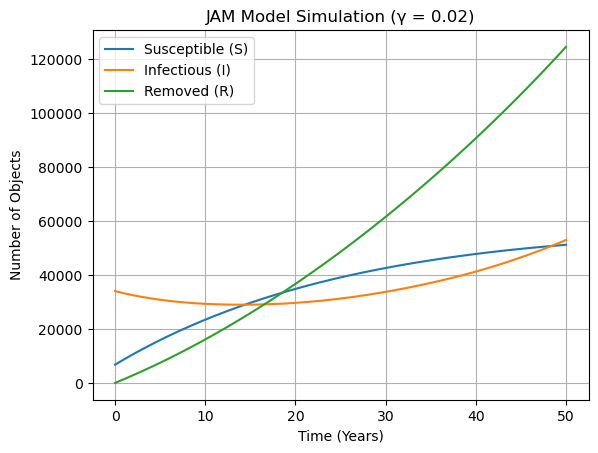

In [16]:
plt.plot(sol2.t, sol2.y[0], label='Susceptible (S)')
plt.plot(sol2.t, sol2.y[1], label='Infectious (I)')
plt.plot(sol2.t, sol2.y[2], label='Removed (R)')
plt.xlabel('Time (Years)')
plt.ylabel('Number of Objects')
plt.title('JAM Model Simulation (γ = 0.02)')
plt.legend()
plt.grid(True)
plt.show()

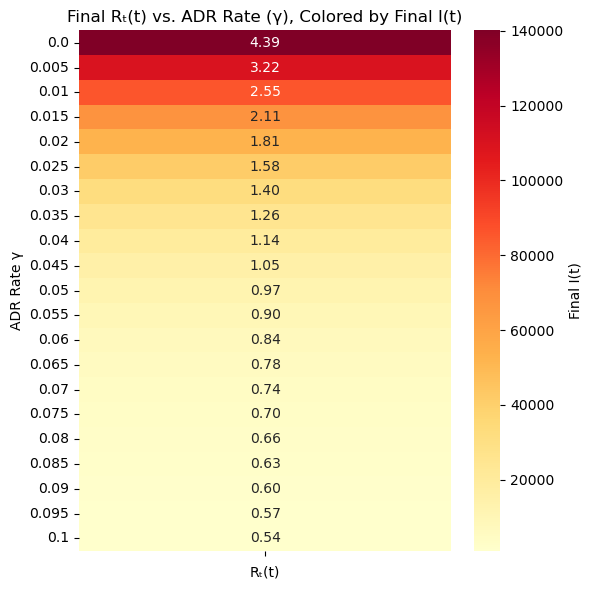

In [17]:
heatmap_data = []

gamma_range = np.linspace(0, 0.1, 21) 

for γ in gamma_range:
    sol = solve_ivp(jam_model, t_span, y0, args=(Λ, β, θ, γ, μ1, μ2), t_eval=t_eval)
    S, I, R = sol.y
    Rt = ((1 + θ) * β * S) / (γ + μ2)
    
    final_I = I[-1]
    max_I = np.max(I)
    final_Rt = Rt[-1]
    max_Rt = np.max(Rt)
    Rt_exceeds_1 = np.any(Rt > 1)
    
    heatmap_data.append({
        "gamma": γ,
        "Final I(t)": final_I,
        "Max I(t)": max_I,
        "Final Rₜ(t)": final_Rt,
        "Max Rₜ(t)": max_Rt
    })

# --- Convert to DataFrame ---
df_heatmap = pd.DataFrame(heatmap_data)

# --- Pivot data for heatmap annotations and color ---
annot_matrix = df_heatmap.set_index("gamma")[["Final Rₜ(t)"]]
color_matrix = df_heatmap.set_index("gamma")[["Final I(t)"]]

# --- Clean column labels ---
annot_matrix.columns = [""]
color_matrix.columns = [""]

# --- Plot heatmap ---
plt.figure(figsize=(6, 6))
sns.heatmap(
    color_matrix,
    annot=annot_matrix,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Final I(t)'},
)
plt.title("Final Rₜ(t) vs. ADR Rate (γ), Colored by Final I(t)")
plt.xlabel("") 
plt.xlabel("Rₜ(t)")
plt.ylabel("ADR Rate γ")
plt.tight_layout()
plt.show()

In [18]:
table_data = []

for γ in gamma_range:
    sol = solve_ivp(jam_model, t_span, y0, args=(Λ, β, θ, γ, μ1, μ2), t_eval=t_eval)
    S, I, R = sol.y
    Rt = ((1 + θ) * β * S) / (γ + μ2)

    table_data.append({
        "γ (ADR rate)": round(γ, 4),
        "Final I(t)": round(I[-1], 2),
        "Max I(t)": round(np.max(I), 2),
        "Final Rₜ(t)": round(Rt[-1], 2),
        "Max Rₜ(t)": round(np.max(Rt), 2),
        "Rₜ(t) > 1?": "Yes" if np.any(Rt > 1) else "No"
    })

# --- Create DataFrame ---
df_table = pd.DataFrame(table_data)

# --- Display table ---
print(df_table.to_string(index=False))

 γ (ADR rate)  Final I(t)  Max I(t)  Final Rₜ(t)  Max Rₜ(t) Rₜ(t) > 1?
        0.000   140151.41 140151.41         4.39       4.39        Yes
        0.005   109999.78 109999.78         3.22       3.22        Yes
        0.010    86258.22  86258.22         2.55       2.55        Yes
        0.015    67628.47  67628.47         2.11       2.11        Yes
        0.020    52936.70  52936.70         1.81       1.81        Yes
        0.025    41353.88  41353.88         1.58       1.58        Yes
        0.030    32304.03  34000.00         1.40       1.40        Yes
        0.035    25263.24  34000.00         1.26       1.26        Yes
        0.040    19796.56  34000.00         1.14       1.14        Yes
        0.045    15433.59  34000.00         1.05       1.05        Yes
        0.050    12021.75  34000.00         0.97       0.97         No
        0.055     9365.59  34000.00         0.90       0.90         No
        0.060     7298.56  34000.00         0.84       0.84         No
      